# 5 · Semi-quantum RBMs and expressive power

A **semi-quantum restricted Boltzmann machine (sqRBM)** keeps the visible units
diagonal ($Z$ only) but gives the hidden units non-commuting Pauli fields
($X$, $Y$, $Z$). Because the bipartite structure has no hidden–hidden couplings,
each hidden unit decouples given the visible configuration, so the visible
marginal has a **closed form** — no $2^{n+m}$ diagonalisation:

$$\tilde p(v) = e^{-\sum_i a_i (-1)^{v_i}} \prod_j \cosh\big(\lVert \Phi_j(v)\rVert\big),
\qquad \Phi_j^P(v) = b_j^P + \sum_i w_{ij}^P (-1)^{v_i},$$

where $\lVert\cdot\rVert$ is the Euclidean norm over the hidden Pauli components.
Cost is $O(2^{n_v}\, n_h)$ — many hidden units are cheap — and the gradients are
closed-form $\tanh$ activations (arXiv:2502.17562, arXiv:2511.11802).

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import qbm
from qbm.losses import SqRBMNLL
from qbm.linalg import partial_trace_hidden

model = qbm.SemiQuantumRBM(n_visible=4, n_hidden=4, hidden_paulis=("X", "Z"))
print(model)

SemiQuantumRBM(n_visible=4, n_hidden=4, hidden_paulis=('X', 'Z'), n_params=44)


### The closed form is exact

We verify the closed-form marginal against the exact dense Gibbs state (which we
can still build for small systems via `to_hamiltonian`).

In [2]:
rng = np.random.default_rng(0)
chk = qbm.SemiQuantumRBM(n_visible=3, n_hidden=2, hidden_paulis=("X", "Z"))
chk.theta = rng.normal(scale=0.6, size=chk.n_params)

pv_closed = chk.visible_probabilities()
rho = qbm.DenseBackend().thermal_state(chk.to_hamiltonian(), chk.theta).density_matrix()
pv_exact = np.real(np.diag(partial_trace_hidden(rho, 3, 2)))
print("max |closed-form - exact| =", np.max(np.abs(pv_closed - pv_exact)))

max |closed-form - exact| = 6.661338147750939e-16


### Train an sqRBM on bars-and-stripes

final KL = 0.00035


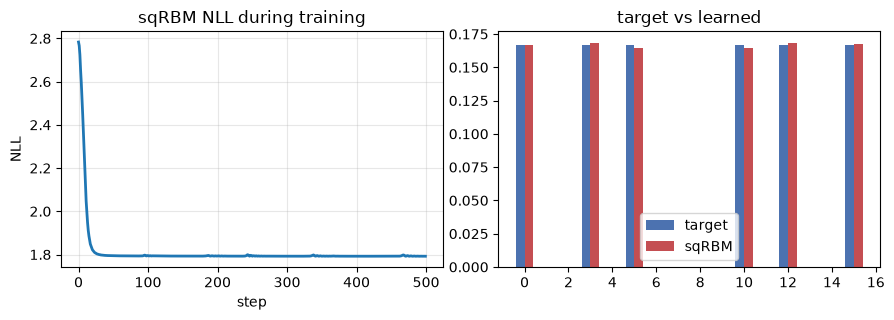

In [3]:
q = qbm.datasets.bars_and_stripes(grid=2)
model.theta = np.random.default_rng(0).normal(scale=0.1, size=model.n_params)
hist = qbm.fit(model, SqRBMNLL(q), qbm.optim.Adam(lr=0.1), steps=500)
print("final KL =", round(model.kl(q), 5))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.3))
axes[0].plot(hist.loss, lw=2); axes[0].set_title("sqRBM NLL during training")
axes[0].set_xlabel("step"); axes[0].set_ylabel("NLL"); axes[0].grid(alpha=0.3)
x = np.arange(len(q)); w = 0.4
axes[1].bar(x - w/2, q, width=w, label="target", color="#4C72B0")
axes[1].bar(x + w/2, model.probabilities(), width=w, label="sqRBM", color="#C44E52")
axes[1].set_title("target vs learned"); axes[1].legend()
plt.tight_layout(); plt.show()

### Quantum hidden units are more expressive

A classical RBM uses commuting ($Z$-only) hidden units; an sqRBM uses
non-commuting ($X$, $Z$) hidden units. We train both for a range of hidden-unit
counts and compare how well they fit the target. The quantum hidden units reach a
lower KL per unit — the expressivity gain of arXiv:2502.17562.

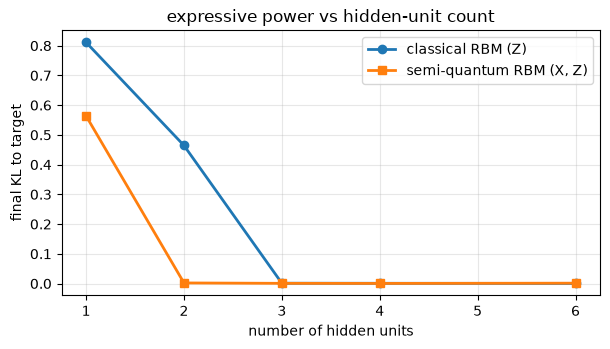

hidden=1:  classical KL=0.8111   semi-quantum KL=0.5637
hidden=2:  classical KL=0.4643   semi-quantum KL=0.0020
hidden=3:  classical KL=0.0011   semi-quantum KL=0.0007
hidden=4:  classical KL=0.0008   semi-quantum KL=0.0004
hidden=6:  classical KL=0.0003   semi-quantum KL=0.0012


In [4]:
def fit_kl(hidden_paulis, n_hidden, steps=400):
    m = qbm.SemiQuantumRBM(n_visible=4, n_hidden=n_hidden, hidden_paulis=hidden_paulis)
    m.theta = np.random.default_rng(0).normal(scale=0.1, size=m.n_params)
    qbm.fit(m, SqRBMNLL(q), qbm.optim.Adam(lr=0.1), steps=steps)
    return m.kl(q)

hidden_counts = [1, 2, 3, 4, 6]
kl_classical = [fit_kl(("Z",), h) for h in hidden_counts]
kl_quantum   = [fit_kl(("X", "Z"), h) for h in hidden_counts]

plt.figure(figsize=(6.2, 3.6))
plt.plot(hidden_counts, kl_classical, "o-", lw=2, label="classical RBM (Z)")
plt.plot(hidden_counts, kl_quantum, "s-", lw=2, label="semi-quantum RBM (X, Z)")
plt.xlabel("number of hidden units"); plt.ylabel("final KL to target")
plt.title("expressive power vs hidden-unit count")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()
for h, kc, kq in zip(hidden_counts, kl_classical, kl_quantum):
    print(f"hidden={h}:  classical KL={kc:.4f}   semi-quantum KL={kq:.4f}")

### Learning a quantum state with hidden units

Hidden units also help when the *target is a quantum state*. The model
distribution is the visible reduced state $\sigma_v = \mathrm{Tr}_h\,\rho_{vh}$, and
we minimise the relative entropy $D(\rho\|\sigma_v)$. Here $\ln\sigma_v$ does not
simplify, so `qbmkit` computes the exact gradient via the Fréchet derivative of
$\log$ (the dense-exact counterpart of the modular-flow lift of arXiv:2512.19819).
We use a realizable target so the optimum is $D=0$.

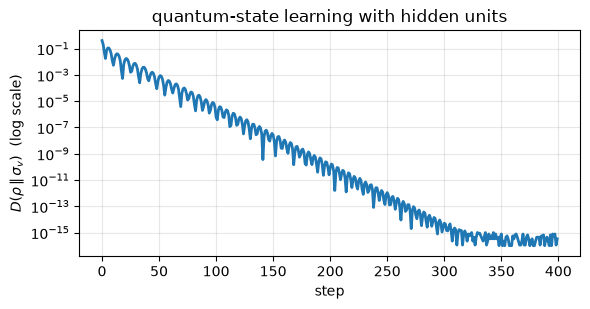

final relative entropy = 3.33e-16


In [5]:
from qbm.losses import MarginalRelativeEntropy

nv, nh = 2, 2
src = qbm.VisibleHiddenQBM(n_visible=nv, n_hidden=nh)
src.theta = np.random.default_rng(5).normal(scale=0.5, size=src.n_params)
target = partial_trace_hidden(src.state().density_matrix(), nv, nh)

model = qbm.VisibleHiddenQBM(n_visible=nv, n_hidden=nh)
model.theta = np.random.default_rng(0).normal(scale=0.1, size=model.n_params)
hist = qbm.fit(model, MarginalRelativeEntropy(target, n_visible=nv),
               qbm.optim.Adam(lr=0.1), steps=400)

plt.figure(figsize=(6, 3.2))
plt.semilogy(np.clip(hist.loss, 1e-16, None), lw=2)
plt.xlabel("step"); plt.ylabel(r"$D(\rho\,\|\,\sigma_v)$  (log scale)")
plt.title("quantum-state learning with hidden units")
plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
print("final relative entropy =", f"{hist.final_loss:.2e}")

### Recap

- The sqRBM closed form makes many hidden units cheap and is exact (matches the
  dense Gibbs marginal).
- Non-commuting hidden units are more expressive than classical ones per unit.
- Hidden-unit models can learn quantum targets via the exact reduced-state
  relative-entropy gradient.